In [1]:
import matplotlib.pyplot as plt
import numpy as np

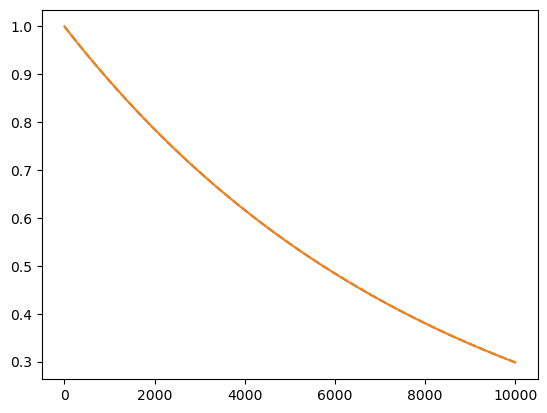

In [3]:
#1)
t_initial = 0
c14_0 = 1
dt = 10 #10 year intervals
t_max = 10000
t_steps = int(t_max/dt)
k = 0.00012097
c_numerical = [c14_0]
for i in range(t_steps-1):
    c_new = c_numerical[-1]*(1 - k*dt)
    c_numerical.append(c_new)
t_values = np.linspace(1,10000,1000)
plt.plot(t_values, c_numerical, linestyle = '--')

#analytical solution

t_analytic = np.linspace(t_initial,t_max,500)
c_analytic = c14_0*np.exp((-k*t_analytic))

plt.plot(t_analytic, c_analytic)

In [4]:
#This is both curves on top of eachother

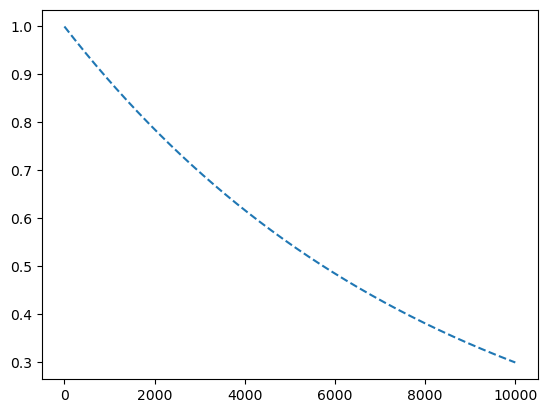

In [5]:
plt.plot(t_values, c_numerical, linestyle = '--')

In [6]:
#Here is just the numeric

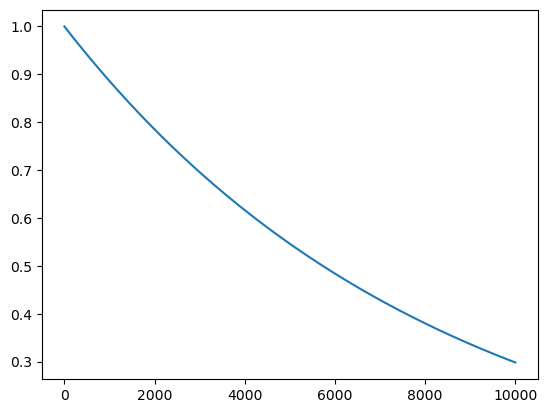

In [7]:
plt.plot(t_analytic, c_analytic)

In [8]:
#Here is just the analytical

In [9]:
half_life = np.log(2)/k
half_life

np.float64(5729.90973431384)

In [10]:
#The half life of Carbon 14 is 5729.91 years

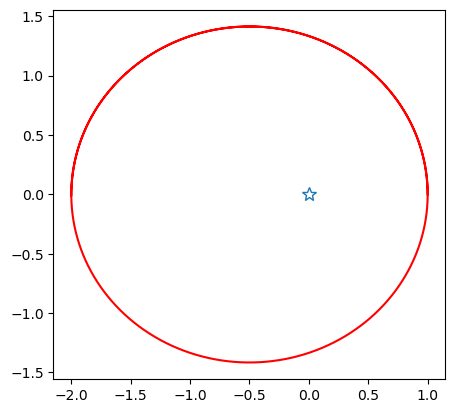

In [18]:
#2)
sun_mass = 10**6
G = 3e-6
dt = 10**-3
max_time = 10
steps = int(max_time/dt)
xx = np.zeros(steps+1)
yy = np.zeros(steps+1)
vx = np.zeros(steps+1)
vy = np.zeros(steps+1)

x_initial = 1
y_initial = 0
vx_initial = 0
vy_initial = 2

xx[0] = x_initial
yy[0] = y_initial
vx[0] = vx_initial
vy[0] = vy_initial

for i in range(steps):
    x_current = xx[i]
    y_current = yy[i]
    vx_current = vx[i]
    vy_current = vy[i]
    r = np.sqrt((x_current**2) + (y_current**2))
    vx[i+1] = (vx_current - (G*sun_mass*x_current*dt/r**3))
    vy[i+1] = (vy_current - G*sun_mass*y_current*dt/r**3)
    
    xx[i+1] = (x_current + vx[i+1]*dt)
    yy[i+1] = (y_current + vy[i+1]*dt)

plt.plot(xx,yy,'r-')
plt.plot(0,0,'*',mfc='w',ms=10)
plt.gca().set_aspect('equal', adjustable = 'box')
plt.show()

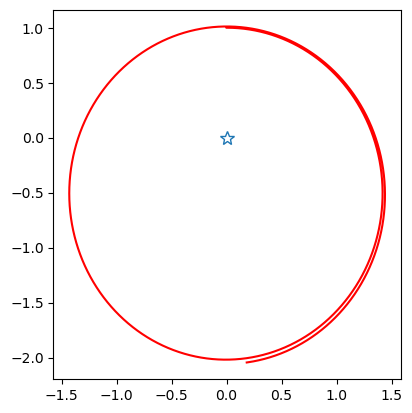

In [28]:
#3)
sun_mass = 10**6
G = 3*(10**(-6))
dt = 10**(-3)
max_time = 10
steps = int(max_time/dt)

def KeplerODE(t,y):
    global mp,ms,G

    r = y[0:2]
    v = y[2:4]
    r_magnitude = np.sqrt(r[0]**2 + r[1]**2)
    F = (-G*sun_mass)/r_magnitude**3
    a = F*r
    dvdt = a
    drdt = v

    return np.concatenate((drdt,dvdt))

x_initial = 1
y_initial = 0
vx_initial = 0
vy_initial = 2

y = np.array([x_initial,y_initial,vx_initial,vy_initial])
xx = np.zeros(steps+1)
yy = np.zeros(steps+1)
xx[0] = x_initial
yy[0] = y_initial

t = 0
for i in range(steps):
    dydt = KeplerODE(t,y)
    y = y + dydt*dt
    xx[i+1] = y[0]
    yy[i+1] = y[1]
    t += dt

plt.plot(yy,xx,'r-')
plt.plot(0,0,'*',mfc='w',ms=10)
plt.gca().set_aspect('equal', adjustable = 'box')
plt.show()